# S2 Transient Response

3C6 Section 2: transient response of a string from deformed initial conditions

## imports and definitions

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
matplotlib.rcParams.update({'font.size': 12,'font.family':'serif'})

from IPython.display import HTML

In [2]:
%matplotlib inline

## Define string class

In [3]:
class String:
    def __init__(self,pos=0.2,Nmodes = 3):
        self.L = 1
        self.c = 1
        self.Y0 = 0.1
        self.a = pos*self.L
        self.T = self.L/self.c
        self.Nx = np.int16(1e3)
        self.Nmodes = np.int32(Nmodes)

        self.x = np.linspace(0,self.L,self.Nx)
    
    def calculate_response(self,t):
        x  = self.x
        L  = self.L
        c  = self.c
        Y0 = self.Y0
        a  = self.a 
        y  = 0
        for nx in range(1,self.Nmodes+1):
            y = y + 2*Y0*L**2*np.sin(nx*np.pi*a/L) / (nx**2*np.pi**2*a*(L-a)) * np.sin(nx*np.pi*x/L) * np.cos(nx*np.pi*c*t/L)

        return x,y
 
    

## Initialise string

Select pluck position 'pos' (as a fraction of string length) and number of modes 'Nmodes' to include in the response

In [10]:
s = String(pos = 0.2, Nmodes = 3)

## Create animation

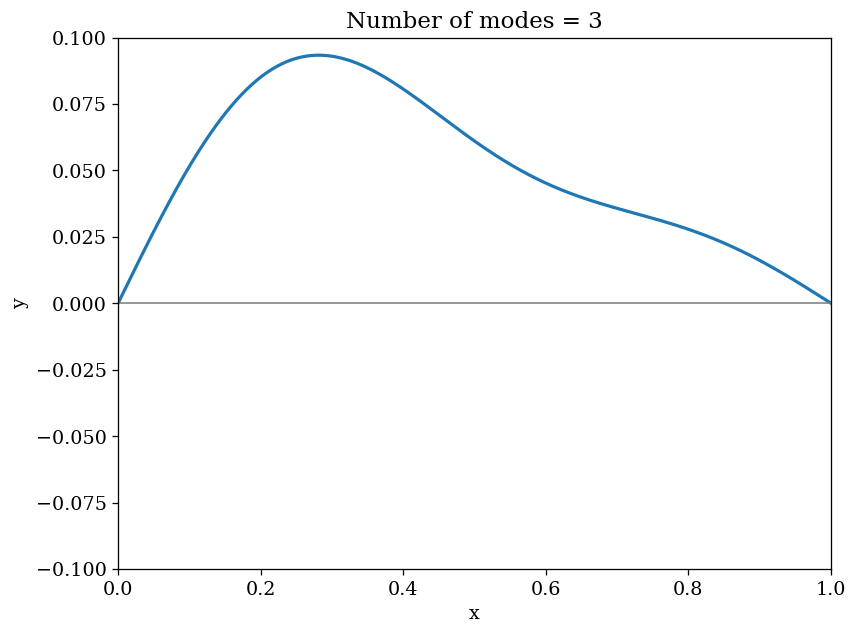

In [11]:
 # First set up the figure, the axis, and the plot element we want to animate
fig = plt.figure(None,figsize=(8,6),dpi=115)
ax = plt.axes(xlim=(0, s.L), ylim=(-s.Y0, s.Y0),xlabel="x",ylabel="y",title="Number of modes = " + str(s.Nmodes))
#plt.close()

line, = ax.plot([], [],  lw=2)
line0, = ax.plot([],[], lw=1, color=[0.5, 0.5, 0.5])
Nframes = np.int32(400)
# initialization function: plot the background of each frame
def init():
    x,y = s.calculate_response(0)
    line.set_data(x, y)
    line0.set_data([0,s.L], [0,0])
    return line,

# animation function.  This is called sequentially
def animate(nt,s,Nframes):
    t = np.linspace(0,2*s.T,Nframes)
    x,y = s.calculate_response(t[nt])
    
    line.set_data(x, y)
    return line,

init()
plt.show()

In [12]:
# call the animator.  blit=True means only re-draw the parts that have changed.
anim = animation.FuncAnimation(fig, animate, fargs=(s,Nframes,),init_func=init,
                               frames=Nframes, interval=10, blit=True)
HTML(anim.to_html5_video())